In [3]:
!pip install kaggle
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving archive.zip to archive (1).zip


{'archive (1).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00%\x9b"V\xe3\xa7%\xb5\xff\xff\xff\xff\xff\xff\xff\xff\x13\x00\x14\x00superstore_data.csv\x01\x00\x10\x00v\xcf\x02\x00\x00\x00\x00\x00\xe8\xdc\x00\x00\x00\x00\x00\x00\xb4}\xdb\xaemIr\xd5;\x12\xff\xc0\x07\xa4t\xf2~y\x04\x1b\x10\x02\x83e#,\x9e\xac\xa2\xfb\xc8]R\xbb\nUU\x83\xf8{r\x8c\x11\x999\xe7Zs!\x99\xdevU\xbbN]N\xec\x9c\x99\x91\x11#"FD\xfe\x87\xdf\xbb\xff\xfe\xfd\x87_\xfe\xfe\xdf\xfc\xf8\xcbo\x7fp\xff\xf6\xf7\x7f\xfa\xdd\x0f\xbf\xfd\xf8\xf3O\xee\xaf~\xf8\xe5\xc7\xdf~\xf8\xe3\xdf\xff\xedo?\xfc\xf6\xa7_\xdd\x7f\xf8\xe9w?\xff\xe3w\xf7\x1f\x7f\xfc\xfd\x1f\xf0\xd7\xff\xfa\xfd\xfbO\xfc\xc5_\xfe\xf6\xf7\x7f\xf1\xa7_\x7f\x9b\xbf\xfc\xc5\xfd\xcd\xf7\xdf}\xff\xe9w\xff\xc7\xfd\xd5O\xbf\xfd\xdd\x8f?}\xff\x15\xbf\xf8w\xbf\xfc\xe9\xc7\xdf\xf8\xab\xbf\xfa\xfe\xc3o\x7f\xfd\xcb\xcf\xf3\x07\xe8\xef\xff\xdd\x8f\xbf\xfe\xe1\xfa\xf7\x7f\xfb\xbf\xbf\x7f\xbf\xfd\x07\xff\xfe\xe7?\xfe\x1e\x7f\xff\xab\xfb\xcf\x7f\xfa\xc7\xbf\xfc\xfe\xc3\x1f\x7f\xfd\xeb?\xfd\xf

In [4]:
import pandas as pd

df = pd.read_csv('/content/superstore_data.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/superstore-data.csv'

In [5]:
import pandas as pd

df = pd.read_csv('/content/superstore_data.csv')
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


I loaded the dataset to understand its structure. I looked at the number of rows, columns, and data types. This helped me see what kind of information is available in this data set.

In [7]:
df.drop_duplicates(inplace=True)

I cleaned the dataset by removing duplicate entries to avoid duplications.

In [8]:
df.isnull().sum()

,0
Id,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [13]:
df['Response'].value_counts()

,count
Response,
0,1906
1,334


In [14]:
df.groupby('Education')['Total_Spending'].mean()

,Total_Spending
Education,
2n Cycle,450.128079
Basic,58.962963
Graduation,569.049689
Master,571.383784
PhD,640.098765


I explored the data to understand campaign responses and spending trends. I checked how many customers responded to campaigns, and analyzed average spending by education level.

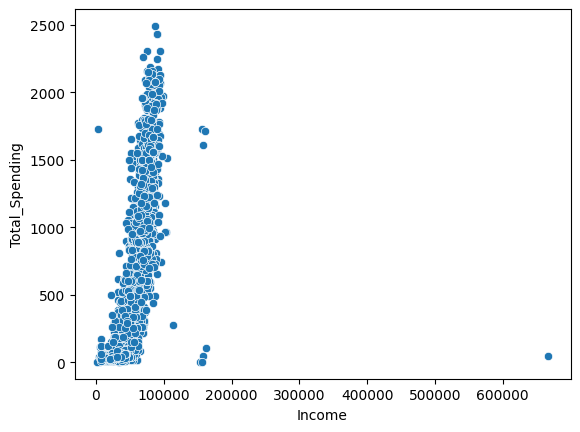

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.show()

I noticed the relationship between income and total spending to see patterns among different customers. Scatter plots and bar charts help identify trends that are not obvious from raw numbers.

Which age group spends the most?

In [16]:
df.groupby(pd.cut(df['Age'], bins=[18,30,45,60,100]))['Total_Spending'].mean()

/tmp/ipykernel_3026/3413633145.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[18,30,45,60,100]))['Total_Spending'].mean()


,Total_Spending
Age,
"(18, 30]",610.081911
"(30, 45]",692.208791
"(45, 60]",151.000000
"(60, 100]",563.000000


Which education level responds better to campaigns?

In [17]:
df.groupby('Education')['Response'].mean()

,Response
Education,
2n Cycle,0.108374
Basic,0.037037
Graduation,0.134871
Master,0.154054
PhD,0.207819


High-spending customers segmentation?

In [19]:
df['High Spenders'] = df['Total_Spending'] > df['Total_Spending'].median()
df.groupby('High_Spenders')['Response'].mean()

,Response
High_Spenders,
False,0.092774
True,0.205541


My Conclusion:
Through this analysis, I was able to identify key patterns in customer behavior.